# 120-TP_TN — ROC & TP/TN Analysis

Compare `117-NewGNN/model_epoch82.pt` vs `119-NewGNN_Cosine/model_epoch30.pt` vs `123-NewGNN_Cosine_finishTraining/model_epoch50.pt` on the fixed test set.

In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv, HeteroConv, SAGEConv
from torch_geometric.transforms import ToUndirected

PRECOMPUTE_DIR = Path("114-precompute")
NB_STEPS_SIM   = 20
HIDDEN_DIM     = 64
NUM_LAYERS     = 3

TEST_EPISODE_IDS = {
    78867640, 78899068, 78982947, 79033183,
    79126912, 79175592, 79228392, 79320069,
}

CKPT_117 = Path("117-NewGNN/model_epoch82.pt")
CKPT_119 = Path("119-NewGNN_Cosine/model_epoch30.pt")
CKPT_123 = Path("123-NewGNN_Cosine_finishTraining/model_epoch50.pt")

In [2]:
_REACHES_KEY = ("planet_step", "reaches", "planet_step")


class OrbitGNN(nn.Module):
    def __init__(self, hidden_dim: int = 64, num_layers: int = 3):
        super().__init__()
        H = hidden_dim
        self.hidden_dim = H

        self.planet_proj      = nn.Linear(4, H, bias=False)
        self.planet_step_proj = nn.Linear(9, H, bias=False)

        self.convs = nn.ModuleList([
            HeteroConv({
                ("planet",      "has_snapshot",     "planet_step"): SAGEConv((H, H), H),
                ("planet_step", "rev_has_snapshot", "planet"):      SAGEConv((H, H), H),
                ("planet_step", "reaches",          "planet_step"): GATConv(
                    (H, H), H, edge_dim=1, heads=1, add_self_loops=False
                ),
                ("planet_step", "rev_reaches",      "planet_step"): SAGEConv((H, H), H),
            }, aggr="sum")
            for _ in range(num_layers)
        ])

        self.pair_mlp = nn.Sequential(
            nn.Linear(2 * H, H),
            nn.ReLU(),
            nn.Linear(H, H // 2),
            nn.ReLU(),
            nn.Linear(H // 2, 1),
        )

    def encode(self, data: HeteroData) -> torch.Tensor:
        x_dict = {
            "planet":      self.planet_proj(data["planet"].x),
            "planet_step": self.planet_step_proj(data["planet_step"].x),
        }
        edge_index_dict = data.edge_index_dict
        edge_attr_map: dict = {}
        if _REACHES_KEY in edge_index_dict:
            try:
                attr = data[_REACHES_KEY].edge_attr
            except AttributeError:
                attr = None
            if attr is not None:
                edge_attr_map[_REACHES_KEY] = attr

        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict, edge_attr_dict=edge_attr_map)
            x_dict = {k: F.relu(v) for k, v in x_dict.items()}

        return x_dict["planet"]

    def score_pairs(
        self,
        h_planet: torch.Tensor,
        src_idx: torch.Tensor,
        tgt_idx: torch.Tensor,
    ) -> torch.Tensor:
        return self.pair_mlp(
            torch.cat([h_planet[src_idx], h_planet[tgt_idx]], dim=-1)
        ).squeeze(-1)

In [3]:
def build_graph(df_s_t, reach_t):
    if reach_t.is_empty():
        raise ValueError("reach_t must be non-empty")
    game_step = int(reach_t["step_src"][0])

    planet_rows = df_s_t.sort("step").unique(subset=["id"], keep="first").sort("id")
    planet_ids  = planet_rows["id"].to_list()
    planet_idx  = {pid: i for i, pid in enumerate(planet_ids)}

    nature_arr  = planet_rows["nature"].to_numpy()
    planet_feat = np.column_stack([
        (nature_arr == "fix").astype(np.float32),
        (nature_arr == "moving").astype(np.float32),
        (nature_arr == "comet").astype(np.float32),
        planet_rows["production"].to_numpy().astype(np.float32) / 5.0,
    ])

    ps_idx_df = df_s_t.with_row_index("ps_idx").select(["id", "step", "ps_idx"])
    owner_arr = df_s_t["owner"].to_numpy()
    step_arr  = df_s_t["step"].to_numpy().astype(np.float32)
    ps_feat   = np.column_stack([
        (step_arr - game_step) / NB_STEPS_SIM,
        df_s_t["x"].to_numpy().astype(np.float32) / 100.0,
        df_s_t["y"].to_numpy().astype(np.float32) / 100.0,
        np.log(np.clip(df_s_t["ships"].to_numpy().astype(np.float32), 1, None)) / np.log(1024),
        (owner_arr == -1).astype(np.float32),
        (owner_arr == 0).astype(np.float32),
        (owner_arr == 1).astype(np.float32),
        (owner_arr == 2).astype(np.float32),
        (owner_arr == 3).astype(np.float32),
    ])

    pid_to_pidx = np.zeros(max(planet_ids) + 1, dtype=np.int64)
    for pid, idx in planet_idx.items():
        pid_to_pidx[pid] = idx
    snap_src = pid_to_pidx[df_s_t["id"].to_numpy()]
    snap_dst = np.arange(len(df_s_t), dtype=np.int64)

    reach_joined = (
        reach_t
        .join(
            ps_idx_df.rename({"id": "id_src", "step": "step_src", "ps_idx": "src_ps_idx"}),
            on=["id_src", "step_src"], how="inner",
        )
        .join(
            ps_idx_df.rename({"ps_idx": "dst_ps_idx"}),
            on=["id", "step"], how="inner",
        )
    )

    data = HeteroData()
    data["planet"].x      = torch.tensor(planet_feat, dtype=torch.float32)
    data["planet_step"].x = torch.tensor(ps_feat,     dtype=torch.float32)
    data["planet", "has_snapshot", "planet_step"].edge_index = torch.tensor(
        np.stack([snap_src, snap_dst]), dtype=torch.long
    )
    if not reach_joined.is_empty():
        ships = reach_joined["ships_sent"].to_numpy().astype(np.float32)
        data["planet_step", "reaches", "planet_step"].edge_index = torch.tensor(
            np.stack([
                reach_joined["src_ps_idx"].to_numpy().astype(np.int64),
                reach_joined["dst_ps_idx"].to_numpy().astype(np.int64),
            ]),
            dtype=torch.long,
        )
        data["planet_step", "reaches", "planet_step"].edge_attr = torch.tensor(
            np.log2(np.clip(ships, 1, None)) / 10.0, dtype=torch.float32
        ).unsqueeze(1)

    return ToUndirected()(data), planet_idx


def build_attack_pairs(df_s_at_t, actions_set, planet_idx, game_step):
    rows = df_s_at_t.select(["id", "owner"]).to_dicts()
    src_planets = [r["id"] for r in rows if r["owner"] == 0 and r["id"] in planet_idx]
    all_planets = [r["id"] for r in rows if r["id"] in planet_idx]

    src_list, tgt_list, label_list = [], [], []
    for id_src in src_planets:
        for id_tgt in all_planets:
            if id_src == id_tgt:
                continue
            src_list.append(planet_idx[id_src])
            tgt_list.append(planet_idx[id_tgt])
            label_list.append(1.0 if (game_step, id_src, id_tgt) in actions_set else 0.0)

    if not src_list:
        empty = torch.zeros(0, dtype=torch.long)
        return empty, empty, torch.zeros(0, dtype=torch.float32)

    return (
        torch.tensor(src_list,   dtype=torch.long),
        torch.tensor(tgt_list,   dtype=torch.long),
        torch.tensor(label_list, dtype=torch.float32),
    )


def evaluate_episode(ep_dir, model):
    df_s    = pl.read_parquet(ep_dir / "df_s.parquet")
    reach   = pl.read_parquet(ep_dir / "reach.parquet")
    actions = pl.read_parquet(ep_dir / "actions.parquet")

    reach = (
        reach
        .group_by(["id_src", "step_src", "id", "ships_sent"])
        .agg(pl.all().sort_by("step").first())
    )

    actions_set = set(zip(
        actions["game_step"].to_list(),
        actions["id_src"].to_list(),
        actions["id"].to_list(),
    ))

    all_scores, all_labels = [], []
    total_loss, n_steps = 0.0, 0

    model.eval()
    with torch.no_grad():
        for t in sorted(reach["step_src"].unique().to_list()):
            reach_t       = reach.filter(pl.col("step_src") == t)
            arrival_steps = reach_t["step"].unique().to_list()
            df_s_t        = df_s.filter(pl.col("step").is_in([t] + arrival_steps))
            df_s_at_t     = df_s.filter(pl.col("step") == t)

            if df_s_t.is_empty() or df_s_at_t.is_empty():
                continue

            data, planet_idx = build_graph(df_s_t, reach_t)
            src_idx, tgt_idx, labels = build_attack_pairs(df_s_at_t, actions_set, planet_idx, t)

            if len(src_idx) == 0:
                continue

            h_planet = model.encode(data)
            logits   = model.score_pairs(h_planet, src_idx, tgt_idx)

            n_pos      = labels.sum().item()
            n_neg      = len(labels) - n_pos
            pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
            loss       = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pos_weight)

            total_loss += loss.item()
            n_steps    += 1
            all_scores.extend(torch.sigmoid(logits).tolist())
            all_labels.extend(labels.tolist())

    return total_loss / max(n_steps, 1), all_scores, all_labels


def collect_scores(model, ep_dirs):
    """Run evaluate_episode on a list of dirs; accumulate (scores, labels)."""
    all_scores, all_labels = [], []
    for ep_dir in ep_dirs:
        try:
            _, scores, labels = evaluate_episode(ep_dir, model)
            all_scores.extend(scores)
            all_labels.extend(labels)
        except Exception as e:
            print(f"  SKIP {ep_dir.name}: {e}")
    return all_scores, all_labels


In [4]:
model_117 = OrbitGNN(hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
model_117.load_state_dict(torch.load(CKPT_117, map_location="cpu", weights_only=True))
model_117.eval()

model_119 = OrbitGNN(hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
model_119.load_state_dict(torch.load(CKPT_119, map_location="cpu", weights_only=True))
model_119.eval()

model_123 = OrbitGNN(hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
model_123.load_state_dict(torch.load(CKPT_123, map_location="cpu", weights_only=True))
model_123.eval()

print(f"Loaded {CKPT_117}")
print(f"Loaded {CKPT_119}")
print(f"Loaded {CKPT_123}")

Loaded 117-NewGNN\model_epoch82.pt
Loaded 119-NewGNN_Cosine\model_epoch30.pt
Loaded 123-NewGNN_Cosine_finishTraining\model_epoch50.pt


In [5]:
ep_dirs   = sorted([d for d in PRECOMPUTE_DIR.iterdir() if d.is_dir()])
test_dirs = [d for d in ep_dirs if int(d.name) in TEST_EPISODE_IDS]

print(f"Test episodes: {len(test_dirs)}")

scores_117, labels_117 = collect_scores(model_117, test_dirs)
scores_119, labels_119 = collect_scores(model_119, test_dirs)
scores_123, labels_123 = collect_scores(model_123, test_dirs)

print(f"117-GNN         — {len(scores_117):,} pairs  |  {int(sum(labels_117))} positives")
print(f"119-Cosine      — {len(scores_119):,} pairs  |  {int(sum(labels_119))} positives")
print(f"123-FinishTrain — {len(scores_123):,} pairs  |  {int(sum(labels_123))} positives")

Test episodes: 8
117-GNN         — 1,018,069 pairs  |  917 positives
119-Cosine      — 1,018,069 pairs  |  917 positives
123-FinishTrain — 1,018,069 pairs  |  917 positives


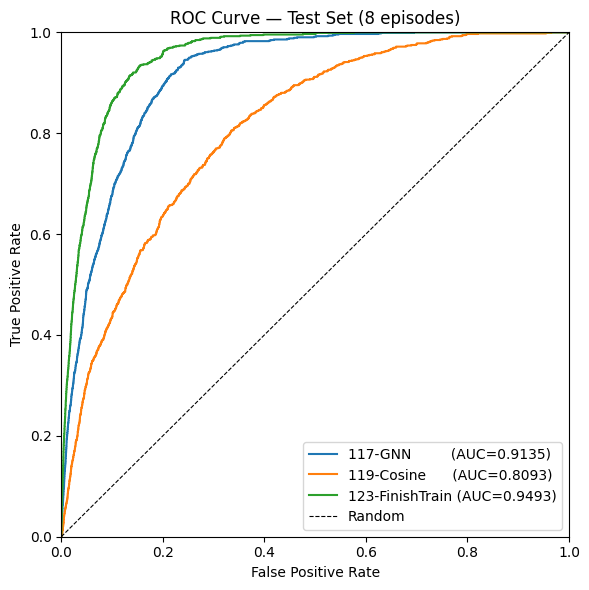

AUC 117-GNN:         0.9135
AUC 119-Cosine:      0.8093
AUC 123-FinishTrain: 0.9493


In [6]:
fpr_117, tpr_117, _ = roc_curve(labels_117, scores_117)
fpr_119, tpr_119, _ = roc_curve(labels_119, scores_119)
fpr_123, tpr_123, _ = roc_curve(labels_123, scores_123)
auc_117 = roc_auc_score(labels_117, scores_117)
auc_119 = roc_auc_score(labels_119, scores_119)
auc_123 = roc_auc_score(labels_123, scores_123)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_117, tpr_117, label=f"117-GNN         (AUC={auc_117:.4f})", linewidth=1.5)
ax.plot(fpr_119, tpr_119, label=f"119-Cosine      (AUC={auc_119:.4f})", linewidth=1.5)
ax.plot(fpr_123, tpr_123, label=f"123-FinishTrain (AUC={auc_123:.4f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set (8 episodes)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("120-TP_TN_roc.png", dpi=150)
plt.show()

print(f"AUC 117-GNN:         {auc_117:.4f}")
print(f"AUC 119-Cosine:      {auc_119:.4f}")
print(f"AUC 123-FinishTrain: {auc_123:.4f}")

In [7]:
def tp_tn_at_threshold(scores, labels, threshold):
    n_pos = int(sum(labels))
    n_neg = len(labels) - n_pos
    tp = sum(1 for s, l in zip(scores, labels) if s >= threshold and l == 1.0)
    tn = sum(1 for s, l in zip(scores, labels) if s <  threshold and l == 0.0)
    return n_pos, n_neg, tp, tn

n_pos_117, n_neg_117, tp_117, tn_117 = tp_tn_at_threshold(scores_117, labels_117, 0.5)
n_pos_119, n_neg_119, tp_119, tn_119 = tp_tn_at_threshold(scores_119, labels_119, 0.5)
n_pos_123, n_neg_123, tp_123, tn_123 = tp_tn_at_threshold(scores_123, labels_123, 0.5)

header = f"{'Model':<18} {'N_pos':>6} {'N_neg':>7} {'TP':>6} {'TN':>7}"
sep    = "-" * len(header)
print("Threshold = 0.5  (test set)")
print(header)
print(sep)
print(f"{'117-GNN':<18} {n_pos_117:>6} {n_neg_117:>7} {tp_117:>6} {tn_117:>7}")
print(f"{'119-Cosine':<18} {n_pos_119:>6} {n_neg_119:>7} {tp_119:>6} {tn_119:>7}")
print(f"{'123-FinishTrain':<18} {n_pos_123:>6} {n_neg_123:>7} {tp_123:>6} {tn_123:>7}")

Threshold = 0.5  (test set)
Model               N_pos   N_neg     TP      TN
------------------------------------------------
117-GNN               917 1017152    423  969346
119-Cosine            917 1017152      0 1017152
123-FinishTrain       917 1017152    565  973397


In [8]:
train_dirs = [d for d in ep_dirs if int(d.name) not in TEST_EPISODE_IDS]
calib_dirs = train_dirs[:8]

print(f"Calibration episodes: {[d.name for d in calib_dirs]}")

calib_scores_117, calib_labels_117 = collect_scores(model_117, calib_dirs)
calib_scores_119, calib_labels_119 = collect_scores(model_119, calib_dirs)
calib_scores_123, calib_labels_123 = collect_scores(model_123, calib_dirs)

def find_best_threshold_f1(scores, labels):
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        tp = sum(1 for s, l in zip(scores, labels) if s >= t and l == 1.0)
        fp = sum(1 for s, l in zip(scores, labels) if s >= t and l == 0.0)
        fn = sum(1 for s, l in zip(scores, labels) if s <  t and l == 1.0)
        denom = 2 * tp + fp + fn
        f1 = (2 * tp / denom) if denom > 0 else 0.0
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1

opt_t_117, opt_f1_117 = find_best_threshold_f1(calib_scores_117, calib_labels_117)
opt_t_119, opt_f1_119 = find_best_threshold_f1(calib_scores_119, calib_labels_119)
opt_t_123, opt_f1_123 = find_best_threshold_f1(calib_scores_123, calib_labels_123)

print(f"117-GNN         optimal threshold: {opt_t_117:.2f}  (calib F1={opt_f1_117:.4f})")
print(f"119-Cosine      optimal threshold: {opt_t_119:.2f}  (calib F1={opt_f1_119:.4f})")
print(f"123-FinishTrain optimal threshold: {opt_t_123:.2f}  (calib F1={opt_f1_123:.4f})")

Calibration episodes: ['78868581', '78868869', '78869135', '78869825', '78870108', '78870540', '78870997', '78871293']
117-GNN         optimal threshold: 0.63  (calib F1=0.0232)
119-Cosine      optimal threshold: 0.32  (calib F1=0.0044)
123-FinishTrain optimal threshold: 0.76  (calib F1=0.0548)


In [9]:
n_pos_117o, n_neg_117o, tp_117o, tn_117o = tp_tn_at_threshold(scores_117, labels_117, opt_t_117)
n_pos_119o, n_neg_119o, tp_119o, tn_119o = tp_tn_at_threshold(scores_119, labels_119, opt_t_119)
n_pos_123o, n_neg_123o, tp_123o, tn_123o = tp_tn_at_threshold(scores_123, labels_123, opt_t_123)

header2 = f"{'Model':<18} {'Threshold':>9} {'N_pos':>6} {'N_neg':>7} {'TP':>6} {'TN':>7}"
sep2    = "-" * len(header2)
print("Optimal Threshold (max-F1 on 8 train episodes)  —  reported on test set")
print(header2)
print(sep2)
print(f"{'117-GNN':<18} {opt_t_117:>9.2f} {n_pos_117o:>6} {n_neg_117o:>7} {tp_117o:>6} {tn_117o:>7}")
print(f"{'119-Cosine':<18} {opt_t_119:>9.2f} {n_pos_119o:>6} {n_neg_119o:>7} {tp_119o:>6} {tn_119o:>7}")
print(f"{'123-FinishTrain':<18} {opt_t_123:>9.2f} {n_pos_123o:>6} {n_neg_123o:>7} {tp_123o:>6} {tn_123o:>7}")

Optimal Threshold (max-F1 on 8 train episodes)  —  reported on test set
Model              Threshold  N_pos   N_neg     TP      TN
----------------------------------------------------------
117-GNN                 0.63    917 1017152    209 1002738
119-Cosine              0.32    917 1017152    143  993495
123-FinishTrain         0.76    917 1017152    188 1010954
